In [16]:
import pyodbc
import pandas as pd

cnxn = pyodbc.connect('DSN=Hermes_DSN',autocommit=True)
cursor = cnxn.cursor()

In [17]:
euro_govs = pd.read_csv('gov_fut.csv')

In [18]:
euro_govs_isin = tuple(euro_govs['isin'].unique())

In [19]:
# parameters
eurex_lei = ('529900LN3S50JPU47S06', '529900VIIHQECIS4ET47', '529900UT4DG0LG5R9O07')

prerefit_start, prerefit_end = '2018-01-01', '2024-04-26'
refit_start,    refit_end    = '2025-01-01', '2026-09-01'   # REFIT transition window 2024 excluded

schema = 'lab_prj_emir_ecb'                   # where the output tables go
sector_table = 'xlab_ecb_prj_sftds_cb_common.pth_sector'

In [20]:
# gov_fut.csv as an inline SQL table, so the CREATE TABLE statements can join to it
gov_fut_sql = '\n    UNION ALL '.join(
    f"SELECT '{r.isin}' AS isin, '{r.country}' AS country, '{r.expiration_date}' AS expiration_date"
    for r in euro_govs.itertuples()
)

In [21]:
# pre-REFIT EA query (Eurex sovereign futures)
def prerefit_query(start, end):
    return f"""
SELECT
    -- identifiers
    tec_ruti,
    reference_period,
    -- counterparties
    CASE WHEN direction = 'BYER' THEN leg1_reporting_cpty_id ELSE leg1_other_cpty_id END AS buyer_id,
    CASE WHEN direction = 'BYER' THEN rep_sector             ELSE oth_sector             END AS buyer_sector,
    CASE WHEN direction = 'BYER' THEN rep_country            ELSE oth_country            END AS buyer_country,
    CASE WHEN direction = 'SLLR' THEN leg1_reporting_cpty_id ELSE leg1_other_cpty_id END AS seller_id,
    CASE WHEN direction = 'SLLR' THEN rep_sector             ELSE oth_sector             END AS seller_sector,
    CASE WHEN direction = 'SLLR' THEN rep_country            ELSE oth_country            END AS seller_country,
    -- product
    product_id,
    product_country,
    expiration_date,
    -- trade terms
    notional,
    notional_currency,
    price,
    quantity
FROM (
    SELECT
        -- identifiers
        e.tec_ruti,
        e.reference_period,
        -- counterparties
        e.leg1_counterparty_side AS direction,
        e.leg1_reporting_cpty_id,
        e.leg1_other_cpty_id,
        e.leg1_reporting_cpty_id_country_code AS rep_country,
        e.leg1_other_cpty_id_country_code     AS oth_country,
        CASE WHEN e.leg1_reporting_cpty_id IN {eurex_lei} THEN 'CCP' ELSE s_rep.sector END AS rep_sector,
        CASE WHEN e.leg1_other_cpty_id     IN {eurex_lei} THEN 'CCP' ELSE s_oth.sector END AS oth_sector,
        -- product
        CAST(e.leg1_product_id AS STRING)    AS product_id,
        g.country          AS product_country,
        g.expiration_date  AS expiration_date,
        -- trade terms
        e.leg1_notional            AS notional,
        e.leg1_notional_currency1  AS notional_currency,
        e.leg1_price_rate          AS price,
        e.leg1_quantity            AS quantity
    FROM crp_emir_ecb.emir_ecb_states_deduplicated e
    JOIN (
        {gov_fut_sql}
    ) g
        ON e.leg1_product_id = g.isin
    LEFT JOIN {sector_table} s_rep
        ON e.leg1_reporting_cpty_id = s_rep.lei
    LEFT JOIN {sector_table} s_oth
        ON e.leg1_other_cpty_id = s_oth.lei
    WHERE e.reference_period BETWEEN '{start}' AND '{end}'
        AND e.leg1_counterparty_side IN ('BYER', 'SLLR')
        AND e.leg1_notional > 0
        AND e.leg1_notional <= 1e11
) base
"""

In [22]:
# REFIT EA query (Eurex sovereign futures)
def refit_query(start, end):
    return f"""
SELECT
    -- identifiers
    tec_ruti,
    reference_period,
    -- counterparties
    CASE WHEN direction = 'BYER' THEN leg1_reporting_cpty_id ELSE leg1_other_cpty_id END AS buyer_id,
    CASE WHEN direction = 'BYER' THEN rep_sector             ELSE oth_sector             END AS buyer_sector,
    CASE WHEN direction = 'BYER' THEN rep_country            ELSE oth_country            END AS buyer_country,
    CASE WHEN direction = 'SLLR' THEN leg1_reporting_cpty_id ELSE leg1_other_cpty_id END AS seller_id,
    CASE WHEN direction = 'SLLR' THEN rep_sector             ELSE oth_sector             END AS seller_sector,
    CASE WHEN direction = 'SLLR' THEN rep_country            ELSE oth_country            END AS seller_country,
    -- product
    product_id,
    product_country,
    expiration_date,
    -- trade terms
    notional,
    notional_currency,
    price,
    quantity
FROM (
    SELECT
        -- identifiers
        e.tec_ruti,
        e.reference_period,
        -- counterparties
        e.leg1_direction AS direction,
        e.leg1_reporting_cpty_id,
        e.leg1_other_cpty_id,
        e.leg1_reporting_cpty_id_country_code_gleif AS rep_country,
        e.leg1_other_cpty_id_country_code_gleif     AS oth_country,
        CASE WHEN e.leg1_reporting_cpty_id IN {eurex_lei} THEN 'CCP' ELSE s_rep.sector END AS rep_sector,
        CASE WHEN e.leg1_other_cpty_id     IN {eurex_lei} THEN 'CCP' ELSE s_oth.sector END AS oth_sector,
        -- product
        CAST(e.leg1_product_isin AS STRING)  AS product_id,
        g.country            AS product_country,
        g.expiration_date    AS expiration_date,
        -- trade terms
        e.leg1_notional_leg1           AS notional,
        e.leg1_notional_leg1_currency  AS notional_currency,
        e.leg1_price                   AS price,
        e.leg1_notional_quantity_leg1  AS quantity
    FROM crp_emir_refit_ecb.emir_refit_ecb_trade_states_deduplicated e
    JOIN (
        {gov_fut_sql}
    ) g
        ON e.leg1_product_isin = g.isin
    LEFT JOIN {sector_table} s_rep
        ON e.leg1_reporting_cpty_id = s_rep.lei
    LEFT JOIN {sector_table} s_oth
        ON e.leg1_other_cpty_id = s_oth.lei
    WHERE e.reference_period BETWEEN '{start}' AND '{end}'
        AND e.leg1_direction IN ('BYER', 'SLLR')
        AND e.leg1_notional_leg1 > 0
        AND e.leg1_notional_leg1 <= 1e11
) base
"""

In [23]:
# pre-REFIT US query (CBOT Treasury futures)
# no contract ISIN on CBOT, so product_id is synthetic: venue, CFI and expiry
def prerefit_us_query(start, end):
    return f"""
SELECT
    -- identifiers
    tec_ruti,
    reference_period,
    -- counterparties
    CASE WHEN direction = 'BYER' THEN leg1_reporting_cpty_id ELSE leg1_other_cpty_id END AS buyer_id,
    CASE WHEN direction = 'BYER' THEN rep_sector             ELSE oth_sector             END AS buyer_sector,
    CASE WHEN direction = 'BYER' THEN rep_country            ELSE oth_country            END AS buyer_country,
    CASE WHEN direction = 'SLLR' THEN leg1_reporting_cpty_id ELSE leg1_other_cpty_id END AS seller_id,
    CASE WHEN direction = 'SLLR' THEN rep_sector             ELSE oth_sector             END AS seller_sector,
    CASE WHEN direction = 'SLLR' THEN rep_country            ELSE oth_country            END AS seller_country,
    -- product
    product_id,
    product_country,
    expiration_date,
    -- trade terms
    notional,
    notional_currency,
    price,
    quantity
FROM (
    SELECT
        -- identifiers
        e.tec_ruti,
        e.reference_period,
        -- counterparties
        e.leg1_counterparty_side AS direction,
        e.leg1_reporting_cpty_id,
        e.leg1_other_cpty_id,
        e.leg1_reporting_cpty_id_country_code AS rep_country,
        e.leg1_other_cpty_id_country_code     AS oth_country,
        CASE WHEN e.leg1_reporting_cpty_id IN {eurex_lei} THEN 'CCP' ELSE s_rep.sector END AS rep_sector,
        CASE WHEN e.leg1_other_cpty_id     IN {eurex_lei} THEN 'CCP' ELSE s_oth.sector END AS oth_sector,
        -- product
        CONCAT('XCBT_FFDPSX_', to_date(e.leg1_maturity_date)) AS product_id,
        'US'                                                 AS product_country,
        to_date(e.leg1_maturity_date)                        AS expiration_date,
        -- trade terms
        e.leg1_notional            AS notional,
        e.leg1_notional_currency1  AS notional_currency,
        e.leg1_price_rate          AS price,
        e.leg1_quantity            AS quantity
    FROM crp_emir_ecb.emir_ecb_states_deduplicated e
    LEFT JOIN {sector_table} s_rep
        ON e.leg1_reporting_cpty_id = s_rep.lei
    LEFT JOIN {sector_table} s_oth
        ON e.leg1_other_cpty_id = s_oth.lei
    WHERE e.reference_period BETWEEN '{start}' AND '{end}'
        AND e.leg1_execution_venue = 'XCBT'
        AND e.leg1_contract_type = 'FUTR'
        AND e.leg1_asset_class = 'INTR'
        AND e.leg1_product_clssfctn = 'FFDPSX'
        AND e.leg1_notional_currency1 = 'USD'
        AND e.leg1_maturity_date IS NOT NULL
        AND e.leg1_counterparty_side IN ('BYER', 'SLLR')
        AND e.leg1_notional > 0
        AND e.leg1_notional <= 1e11
) base
"""

In [24]:
# REFIT US query (CBOT Treasury futures)
# no contract ISIN on CBOT, so product_id is synthetic: venue, CFI and expiry
def refit_us_query(start, end):
    return f"""
SELECT
    -- identifiers
    tec_ruti,
    reference_period,
    -- counterparties
    CASE WHEN direction = 'BYER' THEN leg1_reporting_cpty_id ELSE leg1_other_cpty_id END AS buyer_id,
    CASE WHEN direction = 'BYER' THEN rep_sector             ELSE oth_sector             END AS buyer_sector,
    CASE WHEN direction = 'BYER' THEN rep_country            ELSE oth_country            END AS buyer_country,
    CASE WHEN direction = 'SLLR' THEN leg1_reporting_cpty_id ELSE leg1_other_cpty_id END AS seller_id,
    CASE WHEN direction = 'SLLR' THEN rep_sector             ELSE oth_sector             END AS seller_sector,
    CASE WHEN direction = 'SLLR' THEN rep_country            ELSE oth_country            END AS seller_country,
    -- product
    product_id,
    product_country,
    expiration_date,
    -- trade terms
    notional,
    notional_currency,
    price,
    quantity
FROM (
    SELECT
        -- identifiers
        e.tec_ruti,
        e.reference_period,
        -- counterparties
        e.leg1_direction AS direction,
        e.leg1_reporting_cpty_id,
        e.leg1_other_cpty_id,
        e.leg1_reporting_cpty_id_country_code_gleif AS rep_country,
        e.leg1_other_cpty_id_country_code_gleif     AS oth_country,
        CASE WHEN e.leg1_reporting_cpty_id IN {eurex_lei} THEN 'CCP' ELSE s_rep.sector END AS rep_sector,
        CASE WHEN e.leg1_other_cpty_id     IN {eurex_lei} THEN 'CCP' ELSE s_oth.sector END AS oth_sector,
        -- product
        CONCAT('XCBT_FFDPSX_', to_date(e.leg1_maturity_date)) AS product_id,
        'US'                                                 AS product_country,
        to_date(e.leg1_maturity_date)                        AS expiration_date,
        -- trade terms
        e.leg1_notional_leg1           AS notional,
        e.leg1_notional_leg1_currency  AS notional_currency,
        e.leg1_price                   AS price,
        e.leg1_notional_quantity_leg1  AS quantity
    FROM crp_emir_refit_ecb.emir_refit_ecb_trade_states_deduplicated e
    LEFT JOIN {sector_table} s_rep
        ON e.leg1_reporting_cpty_id = s_rep.lei
    LEFT JOIN {sector_table} s_oth
        ON e.leg1_other_cpty_id = s_oth.lei
    WHERE e.reference_period BETWEEN '{start}' AND '{end}'
        AND e.leg1_execution_venue = 'XCBT'
        AND e.leg1_contract_type = 'FUTR'
        AND e.leg1_asset_class = 'INTR'
        AND e.leg1_product_cfi = 'FFDPSX'
        AND e.leg1_notional_leg1_currency = 'USD'
        AND e.leg1_maturity_date IS NOT NULL
        AND e.leg1_direction IN ('BYER', 'SLLR')
        AND e.leg1_notional_leg1 > 0
        AND e.leg1_notional_leg1 <= 1e11
) base
"""

In [ ]:
# test: one day per regime and region
tests = {
    'prerefit_ea': prerefit_query('2023-07-17', '2023-07-17'),
    'prerefit_us': prerefit_us_query('2023-07-17', '2023-07-17'),
    'refit_ea':    refit_query('2024-07-15', '2024-07-15'),
    'refit_us':    refit_us_query('2024-07-15', '2024-07-15'),
}
dfs = {k: pd.read_sql_query(q, cnxn) for k, q in tests.items()}
for k, d in dfs.items():
    print(k, d.shape, list(d.columns) == list(dfs['refit_ea'].columns))
dfs['refit_us'].head()

In [8]:
# build a table in yearly chunks: CREATE from the first chunk, INSERT INTO for the rest
import time
from datetime import datetime

def year_chunks(start, end):
    chunks, y = [], int(start[:4])
    while True:
        a = max(start, f'{y}-01-01')
        b = min(end, f'{y}-12-31')
        chunks.append((a, b))
        if b == end:
            return chunks
        y += 1

def build_table(table, queries, start, end):
    first = True
    for a, b in year_chunks(start, end):
        for region, q in queries.items():
            t0 = time.time()
            if first:
                cursor.execute(f"DROP TABLE IF EXISTS {table}")
                cursor.execute(f"""
CREATE EXTERNAL TABLE {table}
STORED AS PARQUET TBLPROPERTIES ('external.table.purge'='true')
AS
{q(a, b)}
""")
                first = False
            else:
                cursor.execute(f"INSERT INTO {table}\n{q(a, b)}")
            print(f"{datetime.now():%H:%M:%S}  {table.split('.')[-1]:22s} {region}  {a} to {b}  done in {(time.time() - t0) / 60:5.1f} min")

In [ ]:
# create pre-REFIT table (EA and US), year by year
build_table(f'{schema}.hermesf_fut_prerefit',
            {'EA': prerefit_query, 'US': prerefit_us_query},
            prerefit_start, prerefit_end)

In [26]:
# create REFIT table (EA and US), year by year
build_table(f'{schema}.hermesf_fut_refit',
            {'EA': refit_query, 'US': refit_us_query},
            refit_start, refit_end)

13:50:59  hermesf_fut_refit      EA  2024-04-29 to 2024-12-31  done in   0.4 min
13:51:53  hermesf_fut_refit      US  2024-04-29 to 2024-12-31  done in   0.9 min
13:54:19  hermesf_fut_refit      EA  2025-01-01 to 2025-12-31  done in   2.4 min
13:55:48  hermesf_fut_refit      US  2025-01-01 to 2025-12-31  done in   1.5 min
13:57:21  hermesf_fut_refit      EA  2026-01-01 to 2026-09-01  done in   1.5 min
13:58:21  hermesf_fut_refit      US  2026-01-01 to 2026-09-01  done in   1.0 min


In [27]:
# full series: pre-REFIT 2018-01-01 to 2024-04-26, REFIT 2024-04-29 to 2026-09-01
# numeric columns cast to DOUBLE, the two source tables have different decimal scales
cols = """tec_ruti, reference_period,
       buyer_id, buyer_sector, buyer_country, seller_id, seller_sector, seller_country,
       product_id, product_country, expiration_date,
       CAST(notional AS DOUBLE) AS notional, notional_currency,
       CAST(price AS DOUBLE) AS price, CAST(quantity AS DOUBLE) AS quantity"""
cursor.execute(f"DROP TABLE IF EXISTS {schema}.hermesf_fut")
cursor.execute(f"""
CREATE EXTERNAL TABLE {schema}.hermesf_fut
STORED AS PARQUET TBLPROPERTIES ('external.table.purge'='true')
AS
SELECT {cols} FROM {schema}.hermesf_fut_prerefit
UNION ALL
SELECT {cols} FROM {schema}.hermesf_fut_refit
""")

In [28]:
# check
pd.read_sql_query(f"""
SELECT product_country, MIN(reference_period) AS first_date, MAX(reference_period) AS last_date,
       COUNT(*) AS n_rows, COUNT(DISTINCT product_id) AS n_contracts
FROM {schema}.hermesf_fut
GROUP BY product_country
ORDER BY product_country
""", cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_15988\441612446.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query(f"""


,product_country,first_date,last_date,n_rows,n_contracts
0,DE,2018-01-01,2026-09-01,94239161,144
1,ES,2018-01-03,2026-09-01,662214,36
2,FR,2018-01-02,2026-09-01,14358524,41
3,IT,2018-01-03,2026-09-01,35950838,75
4,US,2018-01-01,2026-09-01,39246987,686


C:\Users\hermesf\AppData\Local\Temp\ipykernel_15988\3164055526.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_net = pd.read_sql_query(query, cnxn)


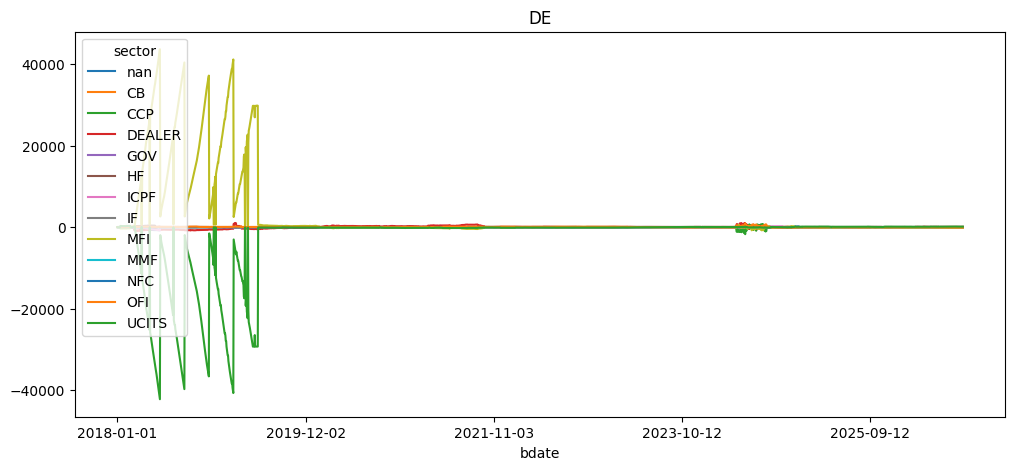

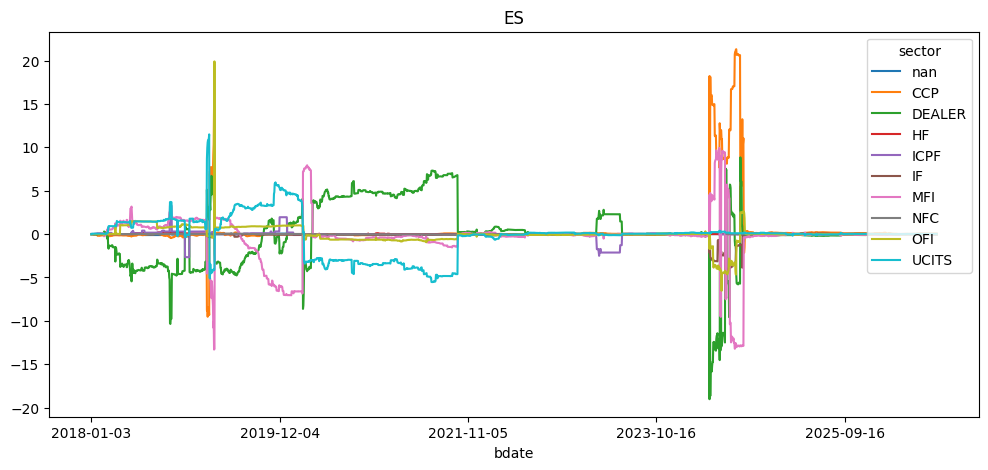

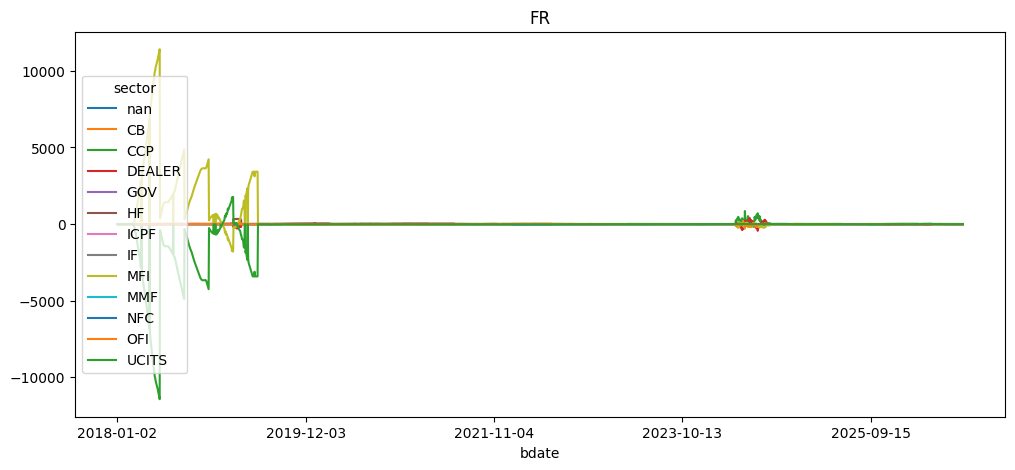

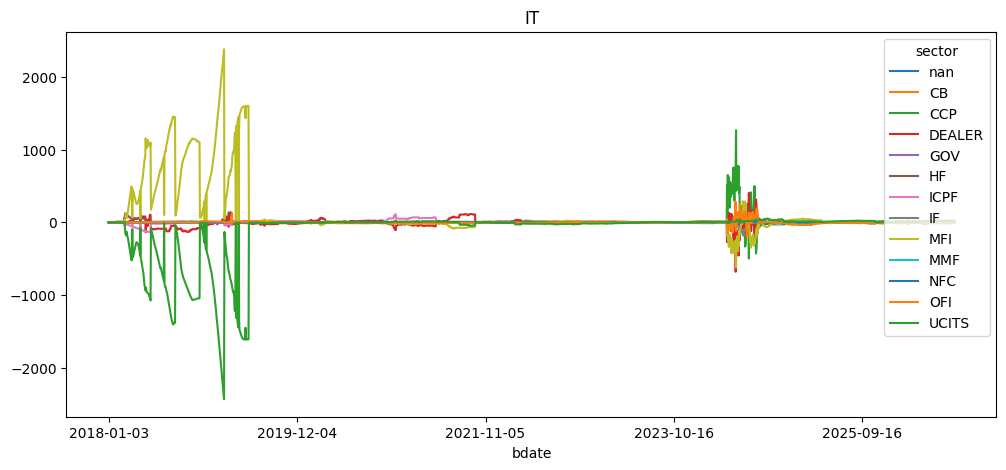

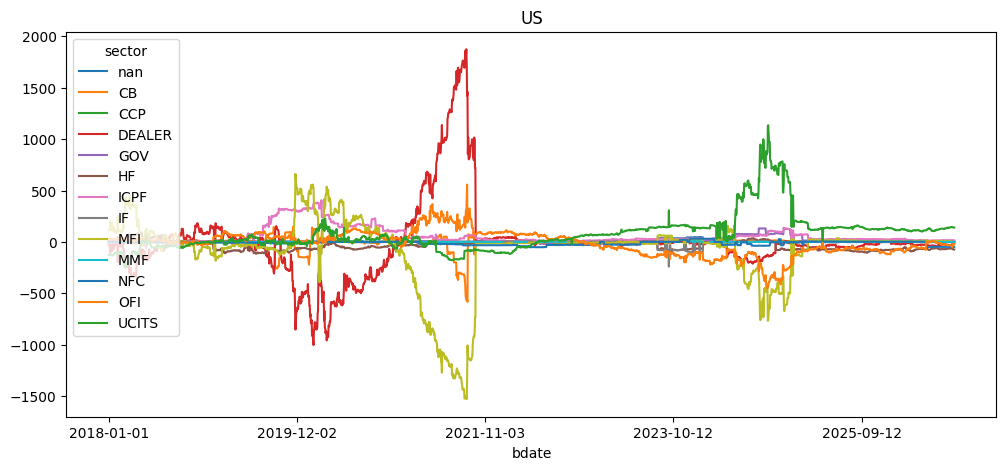

In [33]:
query = f"""
SELECT reference_period AS bdate, product_country, sector,
       SUM(net) / 1e9 AS net_position_bn
FROM (
    SELECT reference_period, product_country, buyer_sector  AS sector,  notional AS net
    FROM {schema}.hermesf_fut
    UNION ALL
    SELECT reference_period, product_country, seller_sector AS sector, -notional AS net
    FROM {schema}.hermesf_fut
) x
GROUP BY reference_period, product_country, sector
ORDER BY reference_period, product_country, sector
"""
df_net = pd.read_sql_query(query, cnxn)

# one chart per region, one line per sector
for country, d in df_net.groupby('product_country'):
    d.pivot(index='bdate', columns='sector', values='net_position_bn').plot(title=country, figsize=(12, 5))

In [34]:
# diagnostics: which counterparty pairs drive the net position of a country on a given day?
def top_pairs(country, day, n=15):
    return pd.read_sql_query(f"""
    SELECT buyer_id, buyer_sector, seller_id, seller_sector,
           COUNT(*) AS n_rows, COUNT(DISTINCT product_id) AS n_contracts,
           SUM(notional) / 1e9 AS notional_bn,
           ROUND(AVG(notional), 0) AS avg_notional,
           ROUND(AVG(price), 2) AS avg_price,
           ROUND(AVG(quantity), 0) AS avg_quantity,
           ROUND(AVG(notional / NULLIF(quantity, 0)), 0) AS avg_notional_per_unit
    FROM {schema}.hermesf_fut
    WHERE product_country = '{country}' AND reference_period = '{day}'
    GROUP BY buyer_id, buyer_sector, seller_id, seller_sector
    ORDER BY notional_bn DESC
    LIMIT {n}
    """, cnxn)

# peaks seen in the charts
top_pairs('DE', '2019-05-31')

C:\Users\hermesf\AppData\Local\Temp\ipykernel_15988\4245369168.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(f"""


,buyer_id,buyer_sector,seller_id,seller_sector,n_rows,n_contracts,notional_bn,avg_notional,avg_price,avg_quantity,avg_notional_per_unit
0,MP6I5ZYZBEU3UXPYFY54,MFI,969500Z0ZW6AFGFWD342,UCITS,189,3,7350.499749,3.889153e+10,135.79,351.0,116396835.0
1,MP6I5ZYZBEU3UXPYFY54,MFI,9695007ZEW1RT7H7ZM94,UCITS,135,3,6986.006660,5.174820e+10,145.44,471.0,118279027.0
2,MP6I5ZYZBEU3UXPYFY54,MFI,549300R35ZWT4M8NDL73,UCITS,134,3,5308.263371,3.961391e+10,151.67,299.0,136856531.0
3,2138002QLML14DYXUL39,UCITS,MP6I5ZYZBEU3UXPYFY54,MFI,127,3,4510.832212,3.551836e+10,126.07,393.0,108810389.0
4,MP6I5ZYZBEU3UXPYFY54,MFI,969500SLEIEO7ZEQBY76,UCITS,189,3,4175.827927,2.209433e+10,135.88,197.0,116466609.0
5,MP6I5ZYZBEU3UXPYFY54,MFI,969500Y6IBU5B605U856,UCITS,230,4,3719.988865,1.617386e+10,145.84,138.0,122748342.0
6,549300R35ZWT4M8NDL73,UCITS,MP6I5ZYZBEU3UXPYFY54,MFI,76,3,1881.205541,2.475270e+10,129.30,232.0,111693366.0
7,MP6I5ZYZBEU3UXPYFY54,MFI,2138002QLML14DYXUL39,UCITS,39,1,1592.119259,4.082357e+10,163.95,495.0,125785083.0
8,MP6I5ZYZBEU3UXPYFY54,MFI,549300IG7G81KR48XN60,UCITS,151,4,1478.233795,9.789628e+09,146.21,81.0,134991658.0
9,MP6I5ZYZBEU3UXPYFY54,MFI,9695005Y53AW889VU821,UCITS,189,3,1290.795892,6.829608e+09,135.98,63.0,116540299.0


In [35]:
top_pairs('US', '2021-06-30')

C:\Users\hermesf\AppData\Local\Temp\ipykernel_15988\4245369168.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(f"""


,buyer_id,buyer_sector,seller_id,seller_sector,n_rows,n_contracts,notional_bn,avg_notional,avg_price,avg_quantity,avg_notional_per_unit
0,5493006QMFDDMYWIAM13,DEALER,96950023SCR9X9F3L662,MFI,859,2,1620.863691,1.886919e+09,140.30,140.0,14414169.0
1,96950023SCR9X9F3L662,MFI,5493006QMFDDMYWIAM13,DEALER,507,2,534.571374,1.054381e+09,155.42,61.0,16476014.0
2,SNZ2OJLFK8MNNCLQOF39,OFI,5493006QMFDDMYWIAM13,DEALER,12,2,179.671413,1.497262e+10,136.28,1032.0,16380354.0
3,5493006QMFDDMYWIAM13,DEALER,549300CQ9NLEHMRCU505,MFI,68,2,123.431289,1.815166e+09,133.51,127.0,14970014.0
4,5493006QMFDDMYWIAM13,DEALER,549300K7Z2KT76WQJD18,CB,10,1,102.185113,1.021851e+10,137.51,772.0,13750875.0
5,549300ZK53CNGEEI6A29,DEALER,ZBUT11V806EZRVTWT807,OFI,10,2,29.136500,2.913650e+09,146.58,19498.0,168612.0
6,549300Y1IIQ0WYJR9F68,ICPF,549300ZK53CNGEEI6A29,DEALER,4,2,22.667042,5.666760e+09,148.46,41123.0,148465.0
7,5299007QVIQ7IO64NX37,OFI,529900FW778QZ5SWL444,NFC,2,1,18.859516,9.429758e+09,NaN,500.0,18859516.0
8,549300CQ9NLEHMRCU505,MFI,5493006QMFDDMYWIAM13,DEALER,56,2,16.824591,3.004391e+08,132.61,19.0,15816902.0
9,9J6MBOOO7BECTDTUZW19,OFI,7LTWFZYICNSX8D621K86,DEALER,20,3,15.779210,7.889605e+08,141.96,5648.0,158484.0


In [36]:
top_pairs('ES', '2024-06-14')

C:\Users\hermesf\AppData\Local\Temp\ipykernel_15988\4245369168.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(f"""


,buyer_id,buyer_sector,seller_id,seller_sector,n_rows,n_contracts,notional_bn,avg_notional,avg_price,avg_quantity,avg_notional_per_unit
0,529900LN3S50JPU47S06,CCP,O2RNE8IBXP4R0TD8PU41,DEALER,9,2,19.083020,2.120336e+09,122.41,25700000.0,123.0
1,G5GSEF7VJP5I7OUK5573,MFI,529900LN3S50JPU47S06,CCP,4,2,18.174915,4.543729e+09,123.08,36750000.0,123.0
2,529900LN3S50JPU47S06,CCP,G5GSEF7VJP5I7OUK5573,MFI,1,1,13.378320,1.337832e+10,122.40,109300000.0,122.0
3,O2RNE8IBXP4R0TD8PU41,DEALER,529900LN3S50JPU47S06,CCP,4,1,7.221122,1.805281e+09,122.30,29400000.0,122.0
4,529900LN3S50JPU47S06,CCP,W22LROWP2IHZNBB6K528,OFI,1,1,7.086960,7.086960e+09,122.40,57900000.0,122.0
5,529900LN3S50JPU47S06,CCP,BFM8T61CT2L1QCEMIK50,IF,2,1,4.364014,2.182007e+09,122.50,17800000.0,122.0
6,96950023SCR9X9F3L662,MFI,529900LN3S50JPU47S06,CCP,1,1,3.577150,3.577150e+09,123.35,29000000.0,123.0
7,BFM8T61CT2L1QCEMIK50,IF,529900LN3S50JPU47S06,CCP,1,1,1.905750,1.905750e+09,123.75,15400000.0,124.0
8,6TJCK1B7E7UTXP528Y04,OFI,529900LN3S50JPU47S06,CCP,1,1,1.823700,1.823700e+09,121.58,15000000.0,122.0
9,529900LN3S50JPU47S06,CCP,549300FH0WJAPEHTIQ77,DEALER,2,1,0.877730,4.388652e+08,122.40,3585500.0,122.0


In [37]:
# diagnostics 2a: scale of notional relative to quantity x price, by country and year
# correct reports sit at 3 (quantity in contracts, 100k face) or 0 (quantity in units of 100 face)
df_scale = pd.read_sql_query(f"""
SELECT product_country, SUBSTR(reference_period, 1, 4) AS yr,
       CASE WHEN quantity IS NULL OR quantity = 0 OR price IS NULL OR price = 0 THEN NULL
            ELSE ROUND(LOG10(notional / (quantity * price))) END AS scale,
       COUNT(*) AS n_rows,
       COUNT(DISTINCT buyer_id) + COUNT(DISTINCT seller_id) AS n_leis,
       ROUND(SUM(notional) / 1e9, 1) AS notional_bn
FROM {schema}.hermesf_fut
GROUP BY 1, 2, 3
ORDER BY 1, 2, 3
""", cnxn)
df_scale.pivot_table(index=['product_country', 'yr'], columns='scale', values='notional_bn', fill_value=0)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_15988\1032271645.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_scale = pd.read_sql_query(f"""


scale                 -23.0  -22.0  -13.0  -12.0  -11.0  -10.0  -9.0   -6.0   \
product_country yr                                                             
DE              2018    0.0    0.0    0.0    0.0    0.0  209.2    0.0    0.0   
                2019    0.0    0.0    0.0    0.0    0.0  159.9    0.0    0.0   
                2020    0.0    0.0    0.0    0.0    0.0   66.0    0.0    0.0   
                2021    0.0    0.0    0.0    0.0    0.0   33.3    0.0    0.0   
                2022    0.0    0.0    0.0    0.0    0.0    1.2    0.0    0.0   
                2023    0.0    0.0    0.0    0.0    0.0    0.7    0.0    0.0   
                2024    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2025    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2026    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
ES              2018    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2019    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2020    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2021    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2022    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2023    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2024    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2025    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2026    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
FR              2018    0.0    0.0    0.0    0.0    0.0    4.2    0.0    0.0   
                2019    0.0    0.0    0.0    0.0    0.0    4.2    0.0    0.0   
                2020    0.0    0.0    0.0    0.0    0.0    2.0    0.0    0.0   
                2021    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2022    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2023    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2024    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2025    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2026    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
IT              2018    0.0    0.0    0.0    0.0    0.0    4.8    0.0    0.0   
                2019    0.0    0.0    0.1    0.0    0.0   11.9    0.0    0.0   
                2020    0.0    0.0    0.1    0.0    0.0    4.2    0.0    0.0   
                2021    0.0    0.0    0.0    0.0    0.0    3.4    0.0    0.0   
                2022    0.0    0.0    0.0    0.0    0.0    0.6    0.0    0.0   
                2023    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2024    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2025    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2026    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
US              2018    0.0    0.0    0.0    0.0    0.0    0.6    0.2    0.0   
                2019    0.0    0.0    0.0    0.0    0.0    9.1    0.0    0.0   
                2020    0.0    0.0    0.0    0.0    0.0    3.5    0.0    0.0   
                2021    0.0    0.0    0.0    0.0    0.0    5.8    0.0    0.0   
                2022    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2023    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
                2024    0.1   14.6    0.0    0.0    0.0    0.0    0.0    0.0   
                2025    0.0   11.3    0.0    0.0    0.0    0.0    0.0    0.0   
                2026    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   

scale                 -5.0    -4.0   ...     7.0      8.0    9.0    10.0  \
product_country yr                   ...                                   
DE              2018    0.0     0.0  ...  26096.4  11012.9  207.1   15.3   
           

In [38]:
# diagnostics 2b: positions still reported after the contract expired
pd.read_sql_query(f"""
SELECT product_country, SUBSTR(reference_period, 1, 4) AS yr,
       COUNT(*) AS n_rows_after_expiry, ROUND(SUM(notional) / 1e9, 1) AS notional_bn
FROM {schema}.hermesf_fut
WHERE reference_period > expiration_date
GROUP BY 1, 2
ORDER BY 1, 2
""", cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_15988\1471614510.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query(f"""


,product_country,yr,n_rows_after_expiry,notional_bn
0,DE,2018,359295,8021.3
1,DE,2019,1041165,34877.3
2,DE,2020,1767779,37410.0
3,DE,2021,1193856,19822.7
4,DE,2022,1391096,12040.9
5,DE,2023,1299978,8151.6
6,DE,2024,749276,58121.3
7,DE,2025,157632,25461.7
8,DE,2026,74101,16960.5
9,ES,2018,542,2.6


In [9]:
# cleaning step 1: reference price per contract and day, built year by year
# price normalised to per 100 and only kept if between 50 and 250, then the average across all reporters
def price_ref_query(start, end):
    return f"""
SELECT product_id, reference_period, AVG(price_norm) AS price_ref, COUNT(*) AS n_prices
FROM (
    SELECT product_id, reference_period,
           CASE WHEN price > 25000 THEN price / 1000
                WHEN price > 2500  THEN price / 100
                WHEN price > 250   THEN price / 10
                ELSE price END AS price_norm
    FROM {schema}.hermesf_fut
    WHERE reference_period BETWEEN '{start}' AND '{end}'
) a
WHERE price_norm BETWEEN 50 AND 250
GROUP BY product_id, reference_period
"""

build_table(f'{schema}.hermesf_fut_price_ref', {'ALL': price_ref_query}, prerefit_start, refit_end)

16:08:35  hermesf_fut_price_ref  ALL  2018-01-01 to 2018-12-31  done in   0.0 min
16:08:36  hermesf_fut_price_ref  ALL  2019-01-01 to 2019-12-31  done in   0.0 min
16:08:37  hermesf_fut_price_ref  ALL  2020-01-01 to 2020-12-31  done in   0.0 min
16:08:38  hermesf_fut_price_ref  ALL  2021-01-01 to 2021-12-31  done in   0.0 min
16:08:39  hermesf_fut_price_ref  ALL  2022-01-01 to 2022-12-31  done in   0.0 min
16:08:41  hermesf_fut_price_ref  ALL  2023-01-01 to 2023-12-31  done in   0.0 min
16:08:42  hermesf_fut_price_ref  ALL  2024-01-01 to 2024-12-31  done in   0.0 min
16:08:43  hermesf_fut_price_ref  ALL  2025-01-01 to 2025-12-31  done in   0.0 min
16:08:44  hermesf_fut_price_ref  ALL  2026-01-01 to 2026-09-01  done in   0.0 min


In [10]:
# cleaning step 2: the cleaned table, built year by year on top of the raw one
#   1. REFIT transition window excluded: nothing between 2024-04-29 and 2024-12-31
#   2. expiry cut off: drop rows reported more than 10 days after the contract expired
#   3. price normalised to per 100, only kept if between 50 and 250, reference price used if missing
#   4. notional rebuild: where notional / (quantity x price) > 3000 the notional is replaced by
#      quantity x 1000 x price (quantity treated as contracts)
def clean_query(start, end):
    return f"""
SELECT r.tec_ruti, r.reference_period,
       r.buyer_id, r.buyer_sector, r.buyer_country, r.seller_id, r.seller_sector, r.seller_country,
       r.product_id, r.product_country, r.expiration_date,
       r.notional AS notional_raw, r.notional_currency, r.price AS price_raw, r.quantity,
       COALESCE(r.price_norm, p.price_ref) AS price_clean,
       CASE WHEN r.quantity IS NULL OR r.quantity <= 0 OR COALESCE(r.price_norm, p.price_ref) IS NULL THEN r.notional
            WHEN r.notional / (r.quantity * COALESCE(r.price_norm, p.price_ref)) > 3000
                 THEN r.quantity * 1000 * COALESCE(r.price_norm, p.price_ref)
            ELSE r.notional END AS notional
FROM (
    SELECT *, CASE WHEN pn BETWEEN 50 AND 250 THEN pn END AS price_norm
    FROM (
        SELECT *,
               CASE WHEN price > 25000 THEN price / 1000
                    WHEN price > 2500  THEN price / 100
                    WHEN price > 250   THEN price / 10
                    ELSE price END AS pn
        FROM {schema}.hermesf_fut
        WHERE reference_period BETWEEN '{start}' AND '{end}'
            AND (reference_period < '2024-04-29' OR reference_period >= '2025-01-01')
            AND reference_period <= to_date(date_add(CAST(expiration_date AS TIMESTAMP), 10))
    ) a
) r
LEFT JOIN {schema}.hermesf_fut_price_ref p
    ON r.product_id = p.product_id AND r.reference_period = p.reference_period
"""

build_table(f'{schema}.hermesf_fut_clean', {'ALL': clean_query}, prerefit_start, refit_end)

16:09:17  hermesf_fut_clean      ALL  2018-01-01 to 2018-12-31  done in   0.2 min
16:09:24  hermesf_fut_clean      ALL  2019-01-01 to 2019-12-31  done in   0.1 min
16:09:32  hermesf_fut_clean      ALL  2020-01-01 to 2020-12-31  done in   0.1 min
16:09:39  hermesf_fut_clean      ALL  2021-01-01 to 2021-12-31  done in   0.1 min
16:09:47  hermesf_fut_clean      ALL  2022-01-01 to 2022-12-31  done in   0.1 min
16:09:54  hermesf_fut_clean      ALL  2023-01-01 to 2023-12-31  done in   0.1 min
16:09:57  hermesf_fut_clean      ALL  2024-01-01 to 2024-12-31  done in   0.1 min
16:10:03  hermesf_fut_clean      ALL  2025-01-01 to 2025-12-31  done in   0.1 min
16:10:06  hermesf_fut_clean      ALL  2026-01-01 to 2026-09-01  done in   0.1 min


C:\Users\hermesf\AppData\Local\Temp\ipykernel_23888\3162178334.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_net_clean = pd.read_sql_query(query_clean, cnxn)


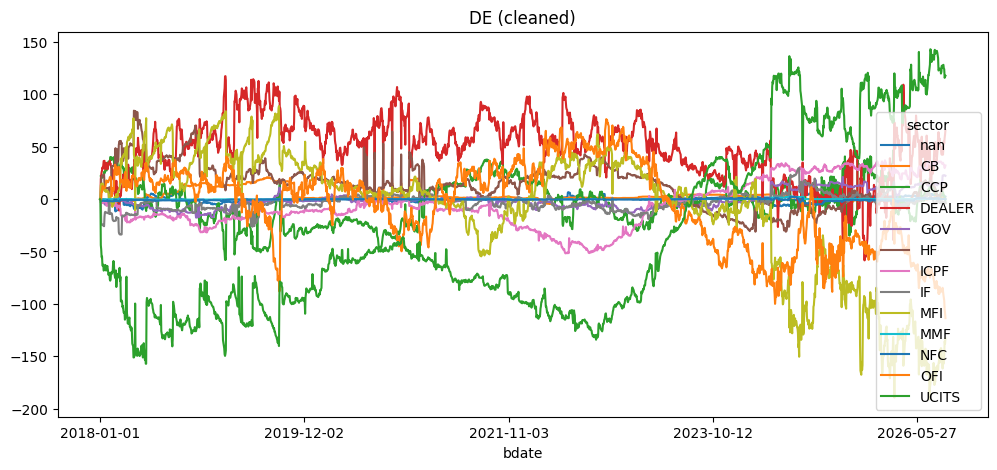

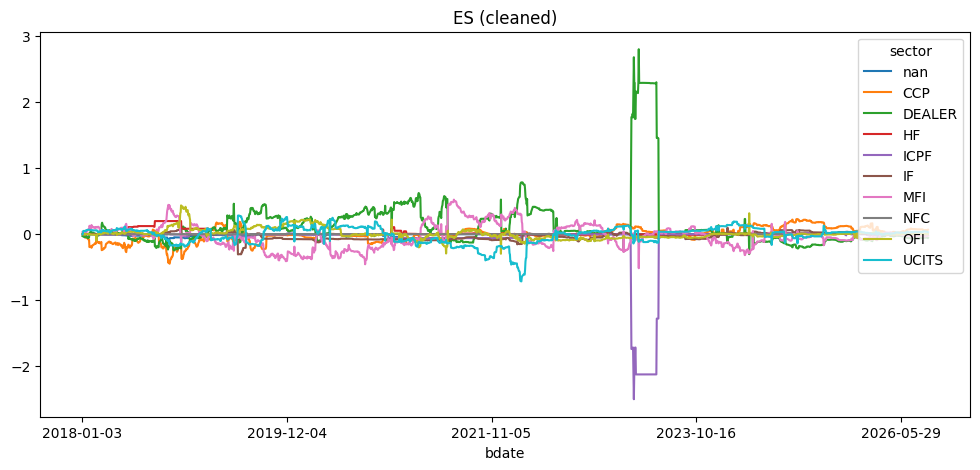

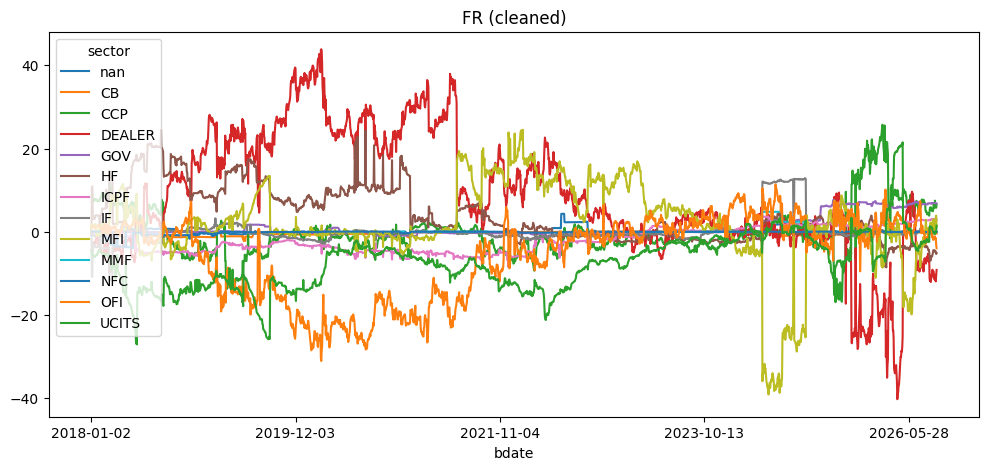

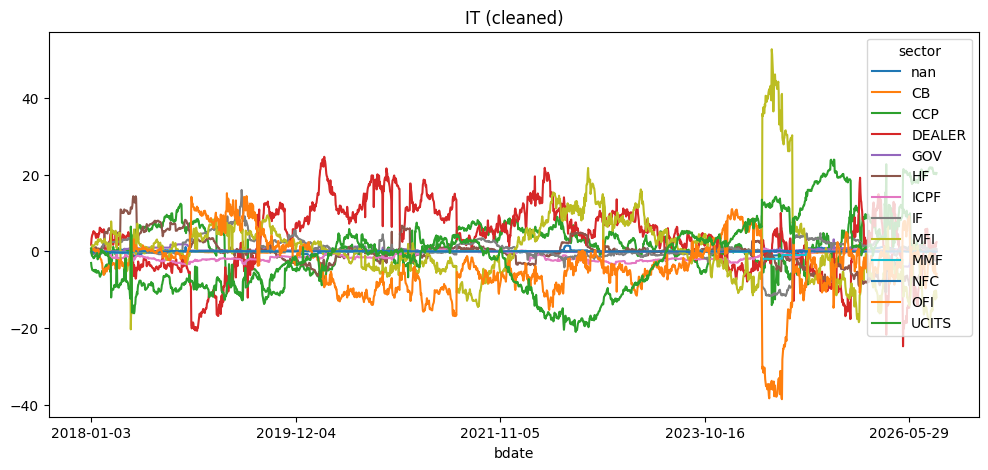

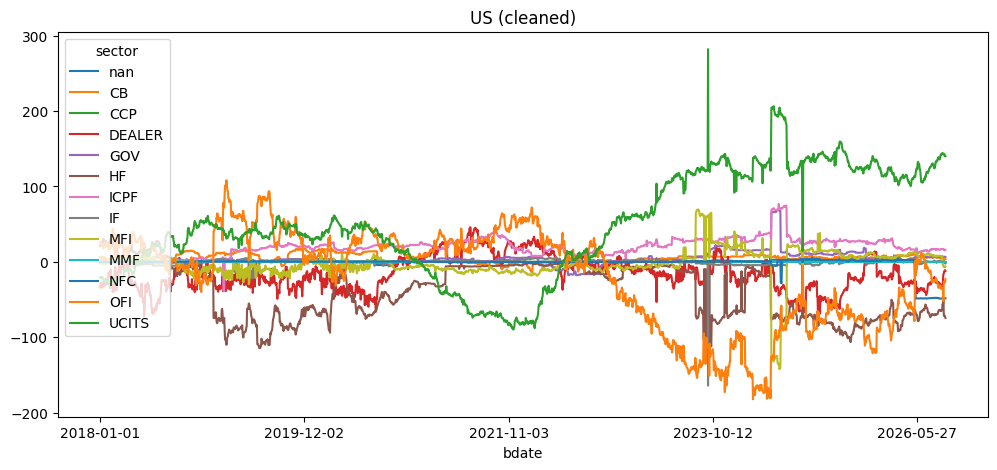

In [11]:
# net positions, cleaned
query_clean = f"""
SELECT reference_period AS bdate, product_country, sector,
       SUM(net) / 1e9 AS net_position_bn
FROM (
    SELECT reference_period, product_country, buyer_sector  AS sector,  notional AS net FROM {schema}.hermesf_fut_clean
    UNION ALL
    SELECT reference_period, product_country, seller_sector AS sector, -notional AS net FROM {schema}.hermesf_fut_clean
) x
GROUP BY reference_period, product_country, sector
ORDER BY reference_period, product_country, sector
"""
df_net_clean = pd.read_sql_query(query_clean, cnxn)

for country, d in df_net_clean.groupby('product_country'):
    d.pivot(index='bdate', columns='sector', values='net_position_bn').plot(title=f'{country} (cleaned)', figsize=(12, 5))

In [12]:
# diagnostics 3: the mid 2019 spike. Peak day per country, then the pairs driving it (cleaned notional)
def top_pairs_clean(country, day, n=15):
    return pd.read_sql_query(f"""
    SELECT buyer_id, buyer_sector, seller_id, seller_sector,
           COUNT(*) AS n_rows, COUNT(DISTINCT product_id) AS n_contracts,
           SUM(notional) / 1e9 AS notional_bn,
           ROUND(AVG(notional), 0) AS avg_notional, ROUND(AVG(notional_raw), 0) AS avg_notional_raw,
           ROUND(AVG(price_clean), 2) AS avg_price, ROUND(AVG(quantity), 0) AS avg_quantity
    FROM {schema}.hermesf_fut_clean
    WHERE product_country = '{country}' AND reference_period = '{day}'
    GROUP BY buyer_id, buyer_sector, seller_id, seller_sector
    ORDER BY ABS(SUM(notional)) DESC
    LIMIT {n}
    """, cnxn)

d19 = df_net_clean[df_net_clean['bdate'].between('2019-01-01', '2019-12-31')]
peaks = d19.loc[d19.groupby('product_country')['net_position_bn'].apply(lambda s: s.abs().idxmax())]
print(peaks)
top_pairs_clean('DE', peaks.set_index('product_country').loc['DE', 'bdate'])

            bdate product_country  sector  net_position_bn
17987  2019-03-05              DE   UCITS      -149.573900
21925  2019-06-05              ES  DEALER         0.460551
29443  2019-12-02              FR  DEALER        39.485924
15317  2019-01-01              IT  DEALER       -20.700879
23023  2019-07-01              US      HF      -114.501220


C:\Users\hermesf\AppData\Local\Temp\ipykernel_23888\617586279.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(f"""


,buyer_id,buyer_sector,seller_id,seller_sector,n_rows,n_contracts,notional_bn,avg_notional,avg_notional_raw,avg_price,avg_quantity
0,0IKLU6X1B10WK7X42C15,DEALER,529900LN3S50JPU47S06,CCP,64,8,85.037664,1.328713e+09,1.328713e+09,152.43,9935.0
1,4PQUHN3JPFGFNF3BB653,DEALER,529900LN3S50JPU47S06,CCP,2130,8,53.101586,2.493032e+07,2.493032e+07,150.16,176.0
2,529900LN3S50JPU47S06,CCP,0IKLU6X1B10WK7X42C15,DEALER,64,9,52.181900,8.153422e+08,8.153422e+08,146.99,6306.0
3,549300ZK53CNGEEI6A29,DEALER,K6Q0W1PS1L1O4IQL9C32,DEALER,19,9,39.127611,2.059348e+09,2.059348e+09,153.86,16848.0
4,529900LN3S50JPU47S06,CCP,4PQUHN3JPFGFNF3BB653,DEALER,1968,9,27.764992,1.410823e+07,1.410823e+07,148.45,101.0
5,LKAJX4ZOK2R6D9THVO59,CB,7LTWFZYICNSX8D621K86,DEALER,17,5,17.652306,1.038371e+09,1.038371e+09,146.60,8601.0
6,8NAV47T0Y26Q87Y0QP81,OFI,549300FH0WJAPEHTIQ77,DEALER,7,7,14.015999,2.002286e+09,2.002286e+09,145.82,15478.0
7,213800GNABQM2M887812,OFI,I9O8MELCUVOTLJABOX92,OFI,209,8,13.978067,6.688070e+07,6.688070e+07,146.66,444.0
8,58PU97L1C0WSRCWADL48,OFI,549300MZ52TRO14U5G05,UCITS,29,2,12.788834,4.409943e+08,4.409943e+08,165.38,2678.0
9,6TJCK1B7E7UTXP528Y04,OFI,XKZZ2JZF41MRHTR1V493,DEALER,7,6,12.472771,1.781824e+09,1.781824e+09,149.97,13345.0


In [13]:
top_pairs_clean('FR', peaks.set_index('product_country').loc['FR', 'bdate'])

C:\Users\hermesf\AppData\Local\Temp\ipykernel_23888\617586279.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(f"""


,buyer_id,buyer_sector,seller_id,seller_sector,n_rows,n_contracts,notional_bn,avg_notional,avg_notional_raw,avg_price,avg_quantity
0,549300ZK53CNGEEI6A29,DEALER,ZBUT11V806EZRVTWT807,OFI,1,1,13.799514,1.379951e+10,1.379951e+10,167.60,82336.0
1,1VUV7VQFKUOQSJ21A208,MFI,96950023SCR9X9F3L662,MFI,4437,2,10.185964,2.295687e+06,2.295687e+06,168.39,14.0
2,K6Q0W1PS1L1O4IQL9C32,DEALER,549300ZK53CNGEEI6A29,DEALER,2,1,7.215515,3.607758e+09,3.607758e+09,167.60,21526.0
3,529900LN3S50JPU47S06,CCP,0IKLU6X1B10WK7X42C15,DEALER,9,2,7.060596,7.845107e+08,7.845107e+08,166.02,4710.0
4,0IKLU6X1B10WK7X42C15,DEALER,549300F35UE0BOM1WJ55,OFI,4,2,6.859233,1.714808e+09,1.714808e+09,166.56,10294.0
5,549300FH0WJAPEHTIQ77,DEALER,GGDZP1UYGU9STUHRDP48,OFI,3,2,6.831779,2.277260e+09,2.277260e+09,167.10,13631.0
6,R0MUWSFPU8MPRO8K5P83,DEALER,549300WCGB70D06XZS54,OFI,3,2,6.491356,2.163785e+09,2.163785e+09,166.02,12938.0
7,549300ZK53CNGEEI6A29,DEALER,K6Q0W1PS1L1O4IQL9C32,DEALER,3,2,6.120245,2.040082e+09,2.040082e+09,165.98,12354.0
8,GGDZP1UYGU9STUHRDP48,OFI,5493006TX0KGRO8WRD64,UCITS,2,2,5.237286,2.618643e+09,2.618643e+09,166.56,15656.0
9,KX1WK48MPD4Y2NCUIZ63,DEALER,96950023SCR9X9F3L662,MFI,5146,2,4.592006,8.923450e+05,8.923450e+05,167.93,5.0


In [ ]:
# diagnostics 4: implied number of contracts per row (notional / (price x 1000)), on the cleaned table
# split by whether the CCP is one of the two sides, bucketed, with rows and notional per bucket
df_contracts = pd.read_sql_query(f"""
SELECT product_country,
       CASE WHEN buyer_sector = 'CCP' OR seller_sector = 'CCP' THEN 'CCP pair' ELSE 'other pair' END AS pair_type,
       CASE WHEN price_clean IS NULL THEN 'no price'
            WHEN notional / (price_clean * 1000) <  10000 THEN 'a: < 10k'
            WHEN notional / (price_clean * 1000) <  50000 THEN 'b: 10k-50k'
            WHEN notional / (price_clean * 1000) < 100000 THEN 'c: 50k-100k'
            WHEN notional / (price_clean * 1000) < 500000 THEN 'd: 100k-500k'
            ELSE 'e: > 500k' END AS contracts_bucket,
       COUNT(*) AS n_rows,
       ROUND(SUM(notional) / 1e9, 1) AS notional_bn,
       SUM(CASE WHEN quantity IS NULL THEN 1 ELSE 0 END) AS n_rows_no_quantity
FROM {schema}.hermesf_fut_clean
GROUP BY 1, 2, 3
ORDER BY 1, 2, 3
""", cnxn)
df_contracts.pivot_table(index=['product_country', 'pair_type'], columns='contracts_bucket', values=['n_rows', 'notional_bn'], fill_value=0)